*Temaa*: Data Science\
*Autora*: Luz Enseñat de Carlos



# Reducción de Dimensionalidad en Iris y MINST



## Principal Components Analysis (PCA)

En el siguiente Proyecto utilizaremos el dataset `Iris` para obtener una nueva representación de los datos es un espacio de menor dimensión del original.

In [74]:
# Cargamos las librerías:

%matplotlib inline

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris


# Cargamos el dataset desde sklearn:

iris = datasets.load_iris()



El dataset contiene datos sobre tres plantas de iris (iris setosa, iris versicolour, e iris virginica), descritas mediante cuatro atributos:

1. Longitud del sépalo (cm)
2. Ancho del sépalo (cm)
3. Longitud del pétalo (cm)
4. Ancho del pétalos (cm)



Asignamos los datos y las etiquetas a variables diferentes.

In [75]:
# Separamos características y etiquetas y vemos cuántas características tenemos:

features = iris.data
label = iris.target
print (features.shape)

(150, 4)


In [76]:
# Como lo que tenemos es un array de sklearn con 4 características, creamos un DataFrame para exploración visual:

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Agregamos también la columna de la clase (target), ya etiquetada:

df['target'] = iris.target

# Mostramos el mapeo de target (índice) a nombre de especie para saber cuál es cuál:

for i, name in enumerate(iris.target_names):
    print(f"{i}: {name}")

df.head(5)

0: setosa
1: versicolor
2: virginica


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Realizamos un análisis exploratorio de los datos. Ploteamos las variables dos a dos, coloreando cada punto según la clase de planta para ver cómo se diferencian.

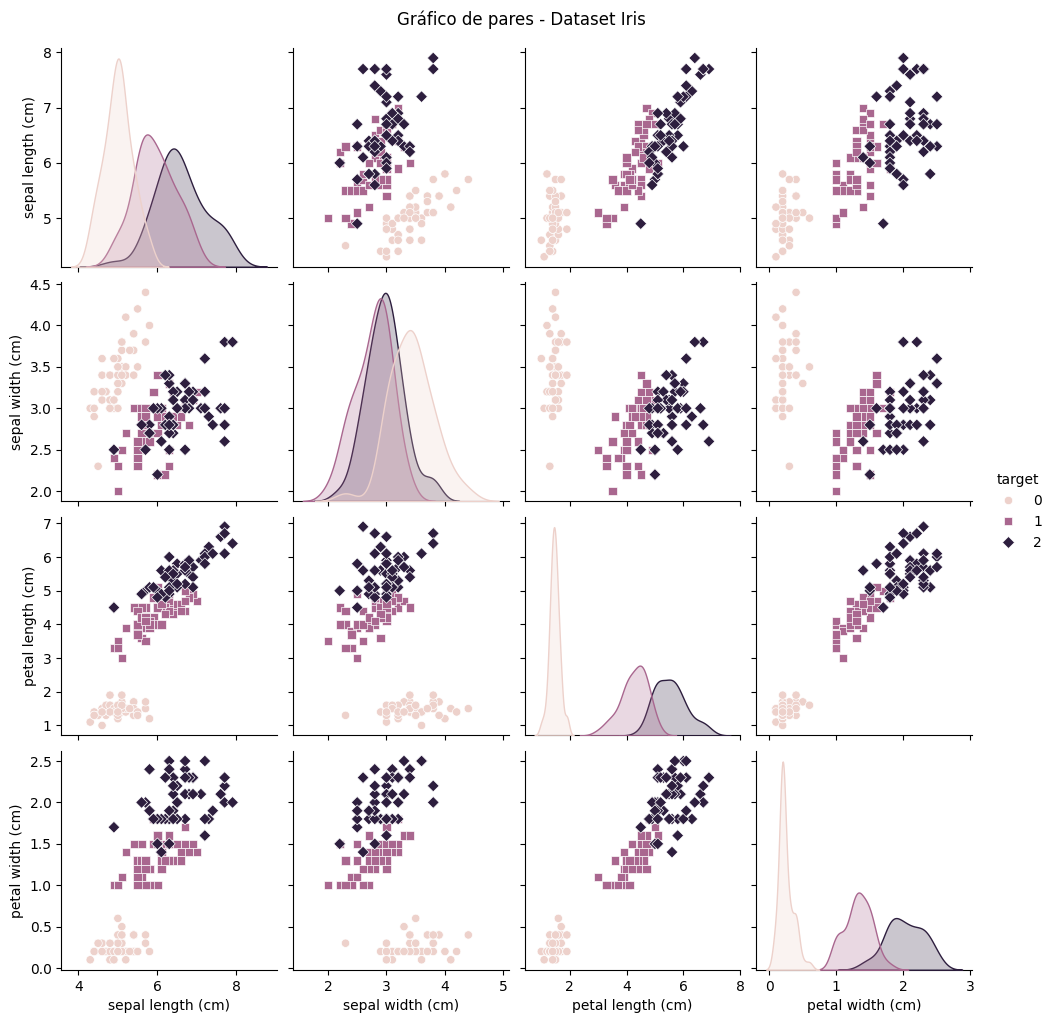

In [77]:
# Ploteamos las variables dos a dos:

sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s", "D"])
plt.suptitle("Gráfico de pares - Dataset Iris", y=1.02)
plt.show()

Viendo los gráficos, está claro que la especie setosa se diferencia de las otras dos, mientras que versicolor y virginica se parecen más.

In [78]:
# Analizamos las variables y comprobamos si se mueven en rangos diferentes para ver la necesidad de normalizar los datos:

df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


Vemos que necesitamos escalar los datos, especialmente porque a continuación vamos a aplicar PCA, por lo que vamos a normalizarlos.

In [79]:
# Definimos sólo las features, sin el target, para normalizar los datos:

features = [x for x in df.columns if x!= 'target']

df [features].head (5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [80]:
# Aplicamos StandardScaler para normalizar los datos de las features:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled.shape

(150, 4)

In [81]:
# Convertimos el array obtenido después de la normalización a Dataframe para visualizarlo mejor, aunque para el PCA trabajaremos con el array:

df_scaled = pd.DataFrame (X_scaled, columns = features)
df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [82]:
# Comprobamos mediante una descripción que tienen media 0 y desviación típica de 1 (al haber normalizaco con StandardScaler):

df_scaled.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71




## Aplicación

Utilizamos el módulo `PCA` de Scikit-learn que contiene los métodos necesarios para obtener los componentes principales de un conjunto de datos y transformarlos al nuevo espacio de representación.



Utilizando el datset iris vamos extraer las tres componentes principales y luego transformar el dataset al nuevo espacio de respresentación de los atributos.
Se proporciona el código.





El proceso se puede descomponer en tres etapas
1. Crear el objeto PCA
2. Extraemos los componentes principales
3. Transformamos los datos

In [83]:
# Creamos el objeto PCA con 3 componentes:

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)
X_scaled_reduced_3 = pca3.transform(X_scaled)

# Verificamos que tenga el shape (150, 3):

print (X_scaled_reduced_3.shape)

(150, 3)


 A continuación generamos un gráfico con los datos transformados.

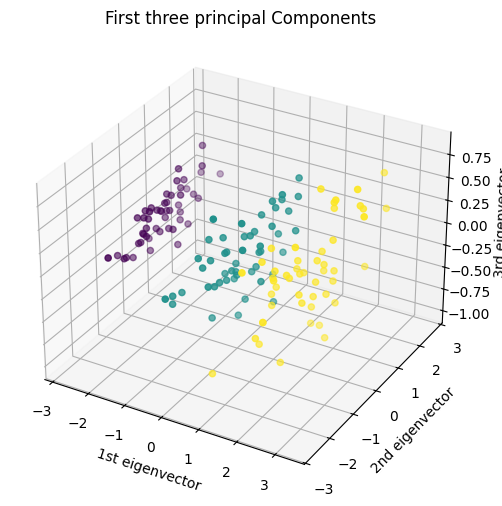

Varianza explicada: [0.72962445 0.22850762 0.03668922]


In [84]:
# Creamos un gráfico 3D:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Asignamos las etiquetas:

sc = ax.scatter(X_scaled_reduced_3[:, 0], X_scaled_reduced_3[:, 1], X_scaled_reduced_3[:, 2], c=label)
ax.set_title("First three principal Components")
ax.set_xlabel("1st eigenvector")
ax.set_ylabel("2nd eigenvector")
ax.set_zlabel("3rd eigenvector")

# Imprimimos el gráfico:

plt.show()

# Imprimimos la varianza explicada:

print("Varianza explicada:", pca3.explained_variance_ratio_)


El atributo `n_components` indica el número de componentes principales que queremos utilizar para reducir la dimensionalidad del dataset. Reducimos a dos dimensiones el conjunto de datos y graficamos los datos en estas dos nuevas dimensiones.



Para reducir a dos dimensiones simplemente tenemos que modificar el atributo `n_components = 2`

In [85]:
# Creamos el objeto PCA con 2 los componentes:

pca2 = PCA(n_components=2)
pca2.fit(X_scaled)
X_scaled_reduced_2 = pca2.transform(X_scaled)

# Verificamos que tenga el shape (150, 2):

print (X_scaled_reduced_2.shape)

(150, 2)


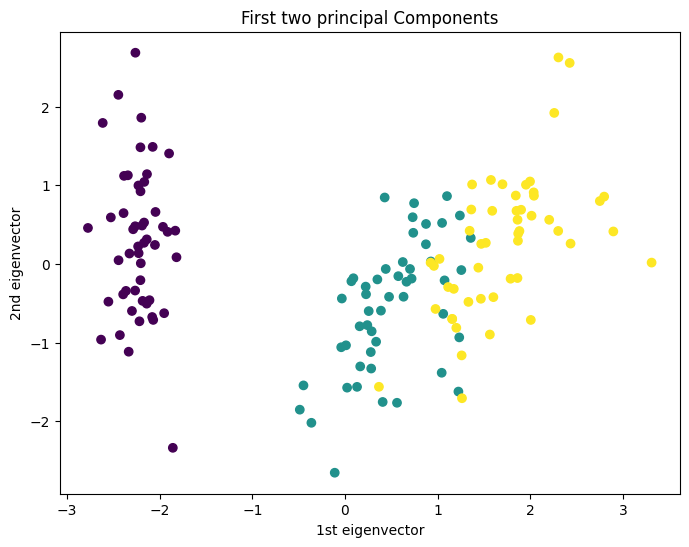

In [86]:
# Creamos un gráfico 2D:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Asignamos las etiquetas:

sc = ax.scatter(X_scaled_reduced_2[:, 0], X_scaled_reduced_2[:, 1], c=label)
ax.set_title("First two principal Components")
ax.set_xlabel("1st eigenvector")
ax.set_ylabel("2nd eigenvector")

# Imprimimos el gráfico:

plt.show()



Para elegir k, se considera un buen número de componentes principales al valor más pequeño de k que  hace que el 99% de la varianza se retenga.



En Scikit-learn podemos obtener el pocentaje de varianza explicada por cada componente principal con el atributo:

```python
PCA.explained_variance_ratio_
```

Vamos a tomar un PCA con todos los componentes posibles, es decir, tantos como variables tenga el dataset inicial

In [87]:
# Aplicamos un PCA con todos los componentes:

pca4 = PCA(n_components=4)
pca4.fit(X_scaled)

# Obtenemos la varianza explicada y la varianza explicada acumulada:

explained_var = pca4.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Mostramos los resultados:

for i, (var, cum_var) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"Componente {i}: {var:.4f} (Acumulado: {cum_var:.4f})")

# Vemos Cuántos componentes necesitamos para alcanzar el 99%:

k = np.argmax(cumulative_var >= 0.99) + 1
print(f"\nNúmero mínimo de componentes para retener ≥99% de la varianza: {k}")

Componente 1: 0.7296 (Acumulado: 0.7296)
Componente 2: 0.2285 (Acumulado: 0.9581)
Componente 3: 0.0367 (Acumulado: 0.9948)
Componente 4: 0.0052 (Acumulado: 1.0000)

Número mínimo de componentes para retener ≥99% de la varianza: 3


Graficaremos ahora la varianza explicada por cada componente y la acumulada.

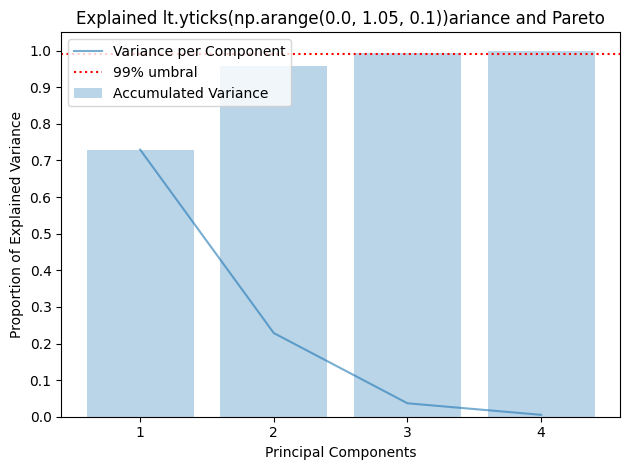

In [88]:
# Graficamos la Varianza Explicada y la Varianza Explicada Acumilada:

plt.plot(range(1,5),explained_var, alpha=0.6, label='Variance per Component')
plt.bar(range(1,5), cumulative_var, alpha=.3, label='Accumulated Variance')
plt.axhline(y=0.99, color='r', linestyle=':', label='99% umbral')
plt.title("Explained lt.yticks(np.arange(0.0, 1.05, 0.1))ariance and Pareto")
plt.xlabel('Principal Components')
plt.ylabel('Proportion of Explained Variance')
plt.xticks(range(1, 5))
plt.yticks(np.arange(0.0, 1.05, 0.1))
plt.tight_layout()
plt.legend()
plt.show()

El primer componente explica ya más del 92% de la Varianza pero, puesto que necesitamos un mínimo del 99%, tendremos que escoger 3 componentes, tal y como se puede observar en el gráfico.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

A continuación vamos a realizar una reducción de dimensionalidad con otro método: t-SNE. Este método, es una técnica de reducción de dimensionalidad  no supervisada y no lineal basada en la distribución de probabilidad de t-Student.

Trabajaremos ahora con el conjunto de datos MINIST que cargaremos directamente de scikit-learn. El conjunto de datos MNIST es uno de los conjuntos de datos más populares y ampliamente utilizados en el campo del aprendizaje automático y la visión por computadora. MNIST (Modified National Institute of Standards and Technology) consiste en un conjunto de imágenes en escala de grises de dígitos escritos a mano, del 0 al 9, recopilados de documentos variados de empleados de la Oficina del Censo de los Estados Unidos y estudiantes de secundaria.

#### MINST data

In [89]:
from sklearn.datasets import load_digits

# Cargamos el conjunto de datos MNIST-like:

digits = load_digits()

# Accedemos a los datos y las etiquetas del target:

X = digits.data
y = digits.target

print(X.shape, y.shape)

(1797, 64) (1797,)


Transformamos la matriz de datos a un dataframe. Símplemente ejecuta el código que se proporciona a continuación.

In [90]:
feat_cols = [ 'pixel'+str(i) for i in range(X.shape[1]) ]

df = pd.DataFrame(X,columns=feat_cols)
df['y'] = y
df['label'] = df['y'].apply(lambda i: str(i))

print('Size of the dataframe: {}'.format(df.shape))
df.head()

Size of the dataframe: (1797, 66)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,4


#### PCA

En primer lugar realizamos una reducción de dimensionalidad utilizando PCA sobre el conjunto de datos MINST. Estandarizamos primeramente los datos y hacemos una reducción a dos componentes.

Dibujamos un scatter plot que represente esta reducción sobre los dos componentes principales.

Pintamos cada punto en función del número que representa, es decir, la variable y o label en el caso del dataframe.

In [91]:
# Definimos sólo las features, sin el target ("y" y "label") , para normalizar los datos:

features = [x for x in df.columns if x!= 'y' if x!= 'label']

df [features].head (5)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [92]:
# Eestandarizamos los datos de las features mediante StandardScaler:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled.shape

(1797, 64)

In [93]:
# Convertimos el array obtenido después de la normalización a Dataframe para visualizarlo mejor, aunque para el PCA trabajaremos con el array:

df_scaled = pd.DataFrame (X_scaled, columns = features)
df_scaled

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
0,0.0,-0.335016,-0.043081,0.274072,-0.664478,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,0.086719,0.208293,-0.366771,-1.146647,-0.505670,-0.196008
1,0.0,-0.335016,-1.094937,0.038648,0.268751,-0.138020,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-0.249010,0.849632,0.548561,-0.505670,-0.196008
2,0.0,-0.335016,-1.094937,-1.844742,0.735366,1.097673,-0.409724,-0.125023,-0.059078,-0.624009,...,0.259230,-0.209785,-0.023596,-0.299081,-1.089383,-2.078218,-0.164037,1.565686,1.695137,-0.196008
3,0.0,-0.335016,0.377661,0.744919,0.268751,-0.844129,-0.409724,-0.125023,-0.059078,1.879691,...,1.072563,-0.209785,-0.023596,-0.299081,0.282736,0.208293,0.241430,0.379040,-0.505670,-0.196008
4,0.0,-0.335016,-1.094937,-2.551014,-0.197863,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-2.306869,0.849632,-0.468564,-0.505670,-0.196008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,-0.335016,-0.253452,-0.432200,0.268751,0.038508,-0.409724,-0.125023,-0.059078,-0.311047,...,0.055897,-0.209785,-0.023596,-0.299081,-0.697349,0.436944,0.646898,0.379040,-0.505670,-0.196008
1793,0.0,-0.335016,0.167290,0.980343,0.268751,0.921145,-0.108958,-0.125023,-0.059078,-0.624009,...,-0.554103,-0.209785,-0.023596,-0.299081,0.086719,0.894246,0.444164,-0.129523,-0.505670,-0.196008
1794,0.0,-0.335016,-0.884566,-0.196776,0.735366,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-0.697349,-0.706312,0.241430,-0.129523,-0.505670,-0.196008
1795,0.0,-0.335016,-0.674195,-0.432200,-1.131092,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.350769,-0.209785,-0.023596,-0.299081,-0.109298,-0.020358,0.849632,0.887602,-0.505670,-0.196008


In [94]:
# Comprobamos mediante una descripción que las características que vemos tienen media 0 y desviación típica de 1 (al haber normalizaco con StandardScaler):

df_scaled.describe().round(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
count,1797.0,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,...,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00
mean,0.0,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,...,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.0,-0.34,-1.09,-2.79,-2.76,-1.02,-0.41,-0.13,-0.06,-0.62,...,-0.76,-0.21,-0.02,-0.30,-1.09,-2.76,-2.39,-1.15,-0.51,-0.20
25%,0.0,-0.34,-0.88,-0.43,-0.43,-1.02,-0.41,-0.13,-0.06,-0.62,...,-0.76,-0.21,-0.02,-0.30,-0.89,-0.25,-0.37,-1.15,-0.51,-0.20
50%,0.0,-0.34,-0.25,0.27,0.27,-0.31,-0.41,-0.13,-0.06,-0.62,...,-0.55,-0.21,-0.02,-0.30,-0.31,0.21,0.44,-0.13,-0.51,-0.20
75%,0.0,-0.34,0.80,0.74,0.74,0.92,-0.41,-0.13,-0.06,0.31,...,0.67,-0.21,-0.02,-0.30,0.87,0.89,0.85,0.89,-0.02,-0.20
max,0.0,8.49,2.27,0.98,0.97,1.80,4.40,14.34,21.17,4.38,...,2.50,13.00,42.38,9.34,2.05,0.89,0.85,1.57,3.41,8.41


Ya observamos que hay algunas características que podríamos eliminar, pero no es el objetivo de esta práctica, por lo que las dejaremos como están de momento.

In [95]:
# Utilizamos PCA para reducir a 2 componentes:

pca2 = PCA(n_components=2)
X_scaled_reduced_2 = pca2.fit_transform(X_scaled)

# Verificamos que tenga el shape (1797, 2):

print (X_scaled_reduced_2.shape)

(1797, 2)


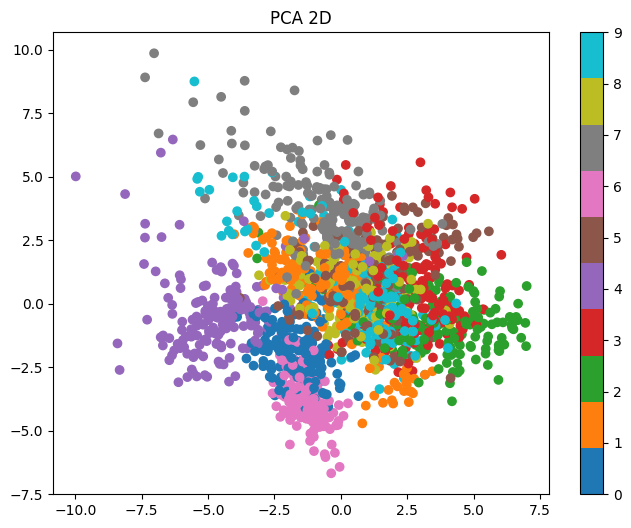

In [96]:
# Dibujamos un scatter plot que representa esta reducción sobre los dos componentes principales:

# Creamos un gráfico 2D:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
plt.scatter(X_scaled_reduced_2[:, 0], X_scaled_reduced_2[:, 1], c=y, cmap='tab10')
plt.title("PCA 2D")
plt.colorbar()

# Imprimimos el gráfico:

plt.show()

Como conclusión del gráfico, podemos decir que las características 0, 4 y 6 están bastante bien definidas, lo que nos da a entender que tienen patrones concretos en los datos originales. Otras características, como la 2 y la 3, se solapan bastante, lo que genera confusión.

El PCA con reducción a 2 componentes ha sido útil para poder ver los datos en un gráfico de 2 ejes y sacar ciertas conclusiones sobre ellos. Por otro lado, para trabajar sobre los datos deberíamos determinar el número de componentes a los que realizar la reducción con PCA cuando la Varianza Explicada Acumulada sea del 99%.

En cualquier caso, para separaciones no lineales ya sabemos que es mejor el método t-SNE.

#### t-SNE

Ahora realizaremos una reducción de dimensionalidad utilizando t-SNE sobre el conjunto de datos MINST. Haremos una reducción a dos componentes y fija una semilla en 0.

Dibujaremos un scatter plot que represente esta reducción sobre los dos dimensiones. Pintaremos cada punto en función del número que representa, es decir, la variable y o label en el caso del dataframe.

In [ ]:
# Aplicamos t-SNE con reducción a 2 componentes:

tsne = TSNE(n_components = 2, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

# Imrpimimos el gráfico:

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.title("t-SNE 2D")
plt.colorbar()
plt.show()

Sin lugar a dudas, este método de reducción de dimensionalidad es mucho mejor y más útil para nuestro dataset que PCA. Todas las características han quedado perfectamente definidas, como se puede observar en el gráfico.

#### PCA & t-SNE

A continuación combinaremos ambas técnicas. Realizaremos una reducción de dimensionalidad utilizando PCA con 10 componentes y posteriormente aplicaremos t-SNE sobre el conjunto de datos resultante. Para t-SNE de nuevo haremos una reducción a dos componentes y fijaremos una semilla en 0.

Dibujaremos un scatter plot que represente esta reducción sobre los dos dimensiones. Pintaremos cada punto en función del número que representa, es decir, la variable y o label en el caso del dataframe.

In [ ]:
# Aplicamos una PCA a 10 componentes:

pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)

# Aplicamos t-SNE sobre el conjunto de datos resultante reduciendo a dos componentes y fijando una semilla en 0:

tsne_comb = TSNE(n_components=2, random_state=0)
X_comb = tsne_comb.fit_transform(X_pca_10)

# Dibujamos un scatter plot que representa esta reducción sobre los dos dimensiones:

plt.figure()
plt.scatter(X_comb[:, 0], X_comb[:, 1], c=y, cmap='tab10')
plt.title("PCA (3D) + t-SNE (2D)")
plt.colorbar()
plt.show()

Este último sistema da bastante buen resultado (no tan bueno como t-SNE a 2 componentes, pero se acerca) y es mucho más rápido computacionalmente, por lo que puede ser una buena solución cuando trabajamos con grandes conjuntos de datos.